In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})

SILVER_FILE = "data/silver/silver_databridge.csv"
OUT_DIR     = "data/gold"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configurações aplicadas ✅")

Configurações aplicadas ✅


In [3]:
df = pd.read_csv('../silver_layer/silver_databridge.csv')

print(f"Registros : {len(df):,}")
print(f"Motores   : {df['ocr_engine'].unique()}")
print(f"Métodos   : {df['normalization_method'].unique()}")

Registros : 24,974
Motores   : <StringArray>
['AZURE_OCR', 'GOOGLE_VISION', 'TESSERACT']
Length: 3, dtype: str
Métodos   : <StringArray>
['RULES_V1', 'RULES_V2', 'ML_V1']
Length: 3, dtype: str


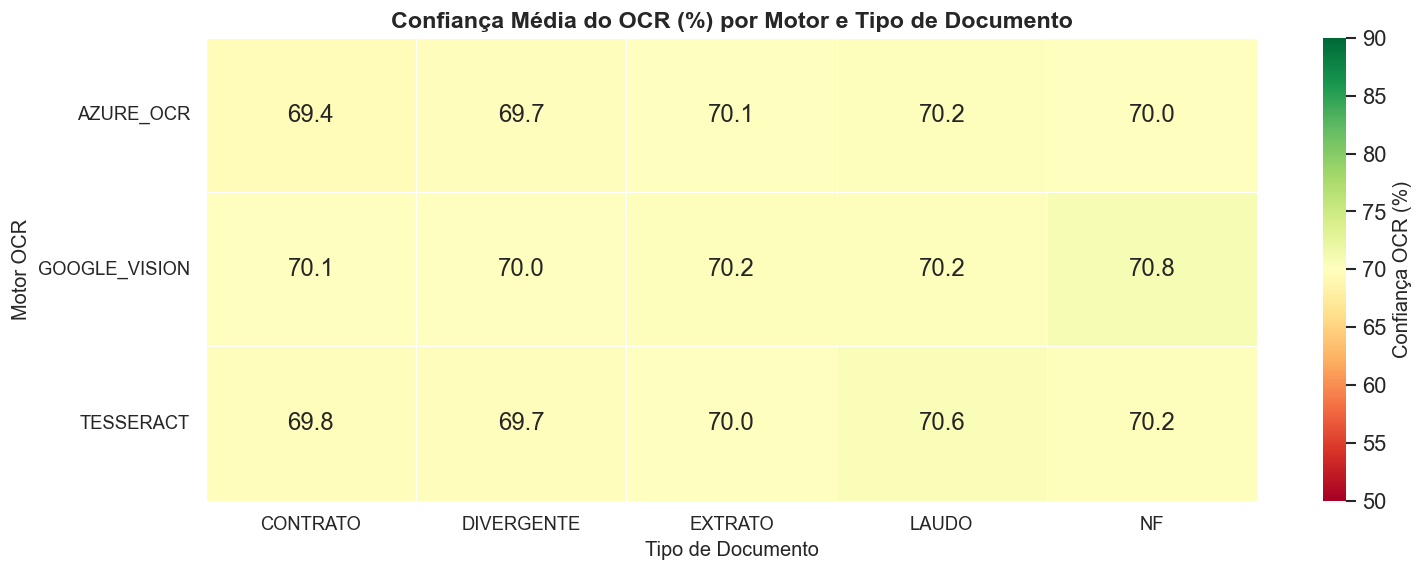

In [5]:
pivot_conf = (
    df.groupby(["ocr_engine", "doc_type"], observed=True)["ocr_confidence"]
    .mean()
    .unstack()
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    pivot_conf,
    annot=True, fmt=".1f", cmap="RdYlGn",
    vmin=50, vmax=90,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "Confiança OCR (%)"},
    ax=ax
)
ax.set_title("Confiança Média do OCR (%) por Motor e Tipo de Documento")
ax.set_xlabel("Tipo de Documento")
ax.set_ylabel("Motor OCR")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sistema_01_confianca_ocr.png", bbox_inches="tight")
plt.show()

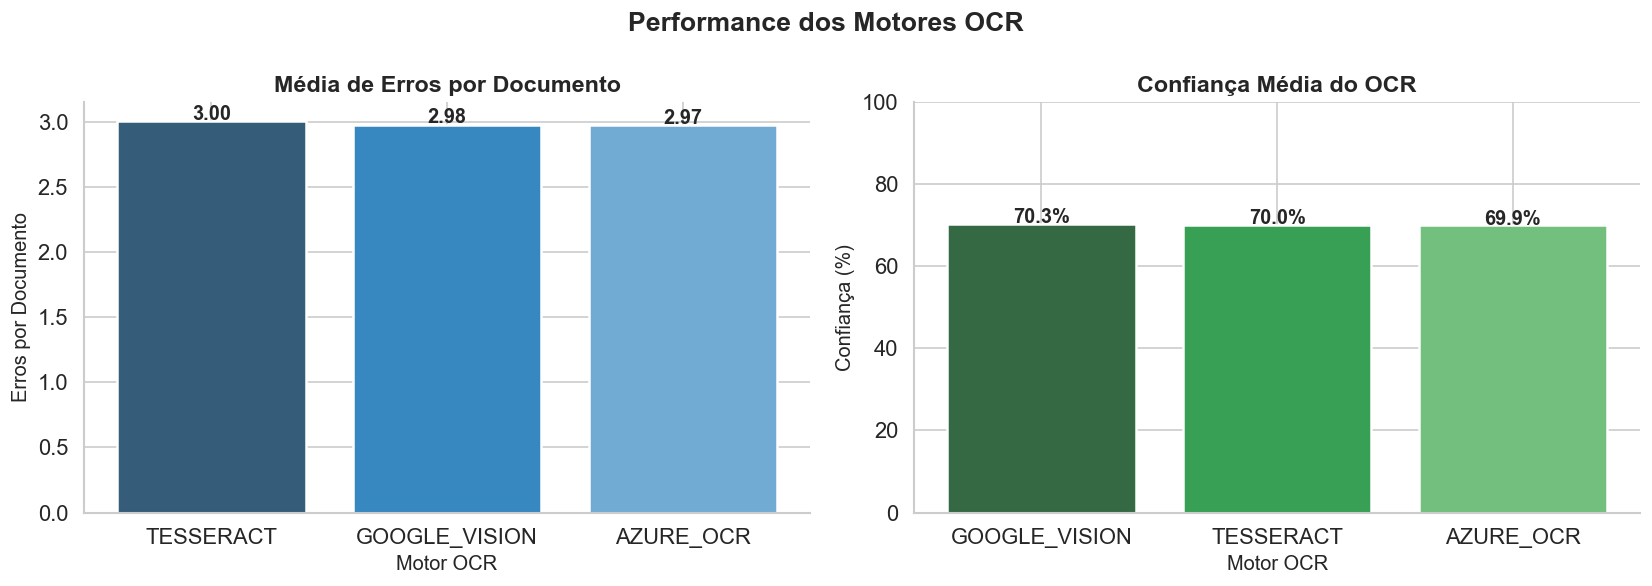

In [6]:
erros_motor = (
    df.groupby("ocr_engine", observed=True)
    .agg(
        erros_medio    = ("ocr_error_count", "mean"),
        erros_total    = ("ocr_error_count", "sum"),
        confianca_media= ("ocr_confidence", "mean"),
        total_docs     = ("ocr_confidence", "count"),
    )
    .round(3)
    .reset_index()
    .sort_values("erros_medio", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance dos Motores OCR", fontsize=16, fontweight="bold")

cores = sns.color_palette("Blues_d", len(erros_motor))

# Erros médios
bars = axes[0].bar(erros_motor["ocr_engine"], erros_motor["erros_medio"],
                   color=cores[::-1], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, erros_motor["erros_medio"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Média de Erros por Documento")
axes[0].set_ylabel("Erros por Documento")
axes[0].set_xlabel("Motor OCR")

# Confiança média
cores2 = sns.color_palette("Greens_d", len(erros_motor))
ordem_conf = erros_motor.sort_values("confianca_media", ascending=False)
bars2 = axes[1].bar(ordem_conf["ocr_engine"], ordem_conf["confianca_media"] * 100,
                    color=cores2[::-1], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars2, ordem_conf["confianca_media"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f"{val*100:.1f}%", ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Confiança Média do OCR")
axes[1].set_ylabel("Confiança (%)")
axes[1].set_xlabel("Motor OCR")
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sistema_02_erros_motor.png", bbox_inches="tight")
plt.show()

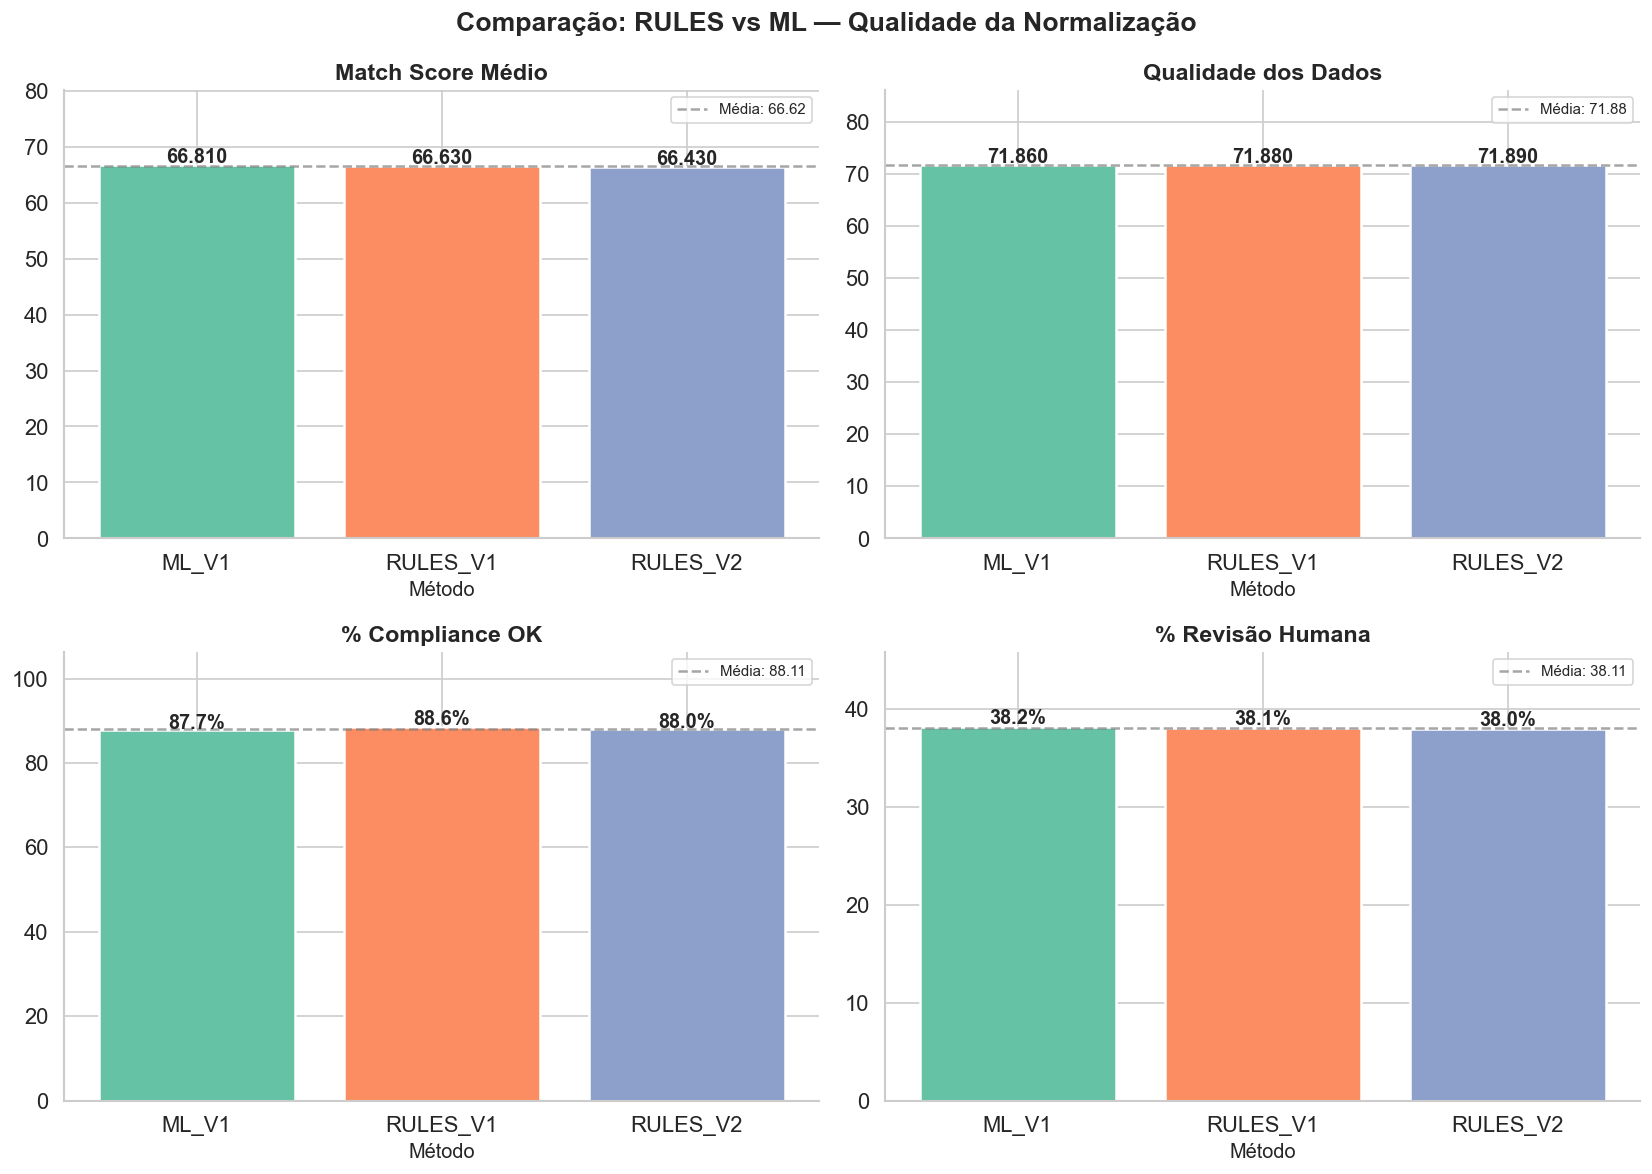

In [7]:
metodos = (
    df.groupby("normalization_method", observed=True)
    .agg(
        total              = ("match_score", "count"),
        match_score_medio  = ("match_score", "mean"),
        data_quality_media = ("data_quality_score", "mean"),
        pct_compliance_ok  = ("compliance_status", lambda x: (x == "OK").mean()),
        pct_revisao_humana = ("requires_human_review", "mean"),
        rule_violations    = ("rule_violations", "mean"),
    )
    .round(4)
    .reset_index()
)

metricas = {
    "match_score_medio" : "Match Score Médio",
    "data_quality_media": "Qualidade dos Dados",
    "pct_compliance_ok" : "% Compliance OK",
    "pct_revisao_humana": "% Revisão Humana",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comparação: RULES vs ML — Qualidade da Normalização",
             fontsize=16, fontweight="bold")
axes = axes.flatten()

paleta = sns.color_palette("Set2", len(metodos))
for i, (col, titulo) in enumerate(metricas.items()):
    vals = metodos[col] * 100 if "pct" in col or "score" in col or "quality" in col else metodos[col]
    bars = axes[i].bar(metodos["normalization_method"], vals,
                       color=paleta, edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f"{val:.1f}%" if "pct" in col else f"{val:.3f}",
                     ha="center", fontsize=12, fontweight="bold")
    axes[i].set_title(titulo)
    axes[i].set_xlabel("Método")
    axes[i].set_ylim(0, vals.max() * 1.2)
    axes[i].axhline(y=vals.mean(), color="gray", linestyle="--",
                    alpha=0.7, label=f"Média: {vals.mean():.2f}")
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sistema_03_rules_vs_ml.png", bbox_inches="tight")
plt.show()

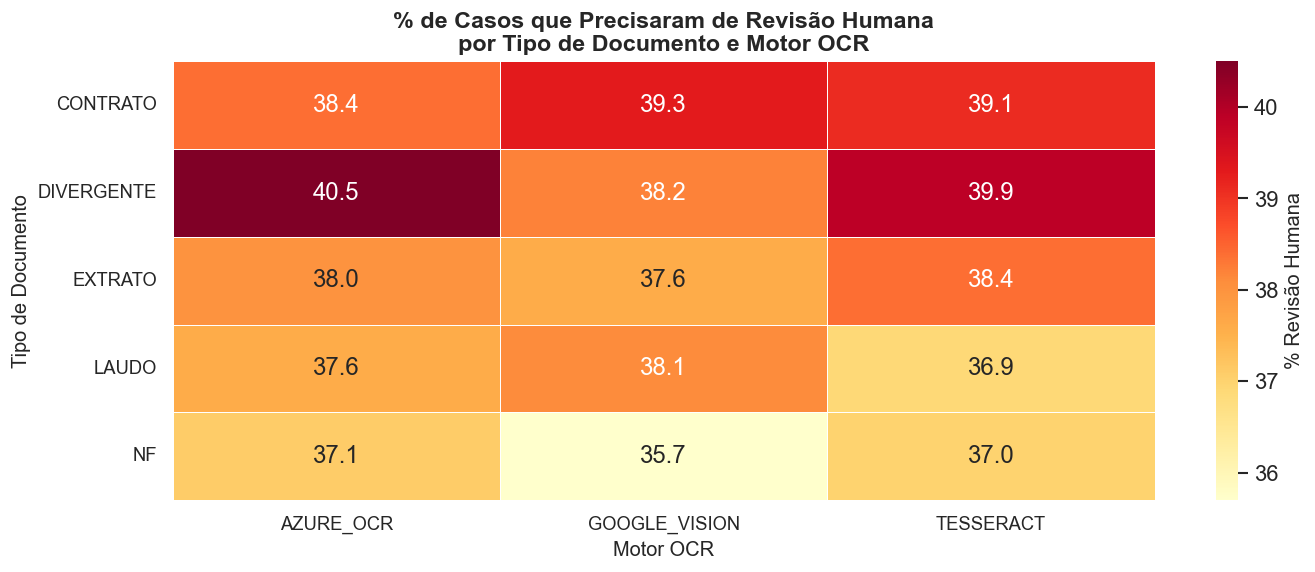

In [8]:
revisao = (
    df.groupby(["doc_type", "ocr_engine"], observed=True)["requires_human_review"]
    .mean()
    .unstack()
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    revisao,
    annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": "% Revisão Humana"},
    ax=ax
)
ax.set_title("% de Casos que Precisaram de Revisão Humana\npor Tipo de Documento e Motor OCR")
ax.set_xlabel("Motor OCR")
ax.set_ylabel("Tipo de Documento")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/sistema_04_revisao_humana.png", bbox_inches="tight")
plt.show()